# Independent-placement GPU hardware replication

## tl;dr

This preregistered confirmation runs six Modal GPU classes on three fresh,
single-use placements each. Every placement contains 1,080 timing observations
(30 repetitions × 36 cells), for **19,440 new observations**. There are zero
execution errors, duplicate repetitions, or invalid workload shapes; no timing
point is removed.

- Every card beats its tuned colocated CPU at `N=8` after 64 transitions are
  fused, in all 18 placements.
- A100-80GB, exact H100, and L40S lose to their colocated CPU in the one-step
  `N=256` cell in all nine corresponding placements.
- H100 has the lowest aggregated fused wall time at `N=256` (0.123 ms), but T4
  has the lowest GPU-only marginal cost (`$0.00243` per billion transitions),
  3.39× below H100 under the frozen Modal rates.

The replicated result is not “old GPUs are faster.” Tiny control kernels expose
dispatch and fusion economics that peak-compute purchasing rules miss.

## Frozen design

Each placement runs `N ∈ {8,16,32,64,128,256}`, `W=8`, `A=1`, and
`H ∈ {1,64}` with resident GPU state plus compiled CPU at one and eight
threads. Thirty timed repetitions follow 20 warm-ups. The primary cross-cloud
unit is the **placement median**. Cross-GPU comparisons use synchronized wall
time; GPU/CPU speedup uses the faster colocated CPU median because host
families vary.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED = ROOT / "data/processed"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)

placement = pd.read_csv(PROCESSED / "hardware-replication-placement-cost.csv")
aggregate = pd.read_csv(PROCESSED / "hardware-replication-aggregate.csv")
quality = pd.read_csv(PROCESSED / "hardware-replication-run-quality.csv")
fusion = pd.read_csv(PROCESSED / "hardware-replication-temporal-fusion.csv")
manifest = json.loads(
    (PROCESSED / "hardware-replication-analysis-manifest.json").read_text()
)

GPU_ORDER = ["T4", "L4", "A10", "L40S", "A100-80GB", "H100!"]
GPU_COLORS = {
    "T4": "#6B7280", "L4": "#0B6E75", "A10": "#2563EB",
    "L40S": "#7C3AED", "A100-80GB": "#D97706", "H100!": "#DC2626",
}
sns.set_theme(style="whitegrid", context="notebook")
manifest["hypotheses"]

{'R1_all_h64_n8_placements_speedup_gt_1': True,
 'R2_fusion_advantage_gt_1_every_placement_population': True,
 'R3_cheaper_gpu_beats_h100_cost_in_all_three_placements': True,
 'R3_qualifying_gpus': ['A10', 'L4', 'L40S', 'T4'],
 'R4_price_wall_time_spearman': -0.48571428571428577,
 'R4_price_wall_time_spearman_below_0_8': True,
 'R5_failed_placement_counts': {'A100-80GB': 3, 'H100!': 3, 'L40S': 3},
 'R5_two_high_cards_fail_one_step_in_two_of_three_placements': True,
 'complete_expected_18_placements': True}

## Integrity and placement variation

In [2]:
assert len(quality) == 18
assert quality["rows"].sum() == 19_440
assert (quality["rows"] == 1080).all()
assert (quality["cases"] == 36).all()
assert (quality["execution_error_rows"] == 0).all()
assert (quality["duplicate_case_repetitions"] == 0).all()
assert (quality["invalid_shapes"] == 0).all()
assert len(placement) == 216
assert (aggregate["placements"] == 3).all()
assert all(
    manifest["hypotheses"][key]
    for key in [
        "complete_expected_18_placements",
        "R1_all_h64_n8_placements_speedup_gt_1",
        "R2_fusion_advantage_gt_1_every_placement_population",
        "R3_cheaper_gpu_beats_h100_cost_in_all_three_placements",
        "R4_price_wall_time_spearman_below_0_8",
        "R5_two_high_cards_fail_one_step_in_two_of_three_placements",
    ]
)
quality[[
    "requested_gpu", "placement_replicate", "hardware", "cpu_vendor",
    "cpu_family", "cpu_model", "median_cell_cv", "p90_cell_cv",
    "cells_cv_over_10pct",
]].sort_values(["requested_gpu", "placement_replicate"])

,requested_gpu,placement_replicate,hardware,cpu_vendor,cpu_family,cpu_model,median_cell_cv,p90_cell_cv,cells_cv_over_10pct
6,A10,1,NVIDIA A10,GenuineIntel,6,106,0.062748,0.307252,15
7,A10,2,NVIDIA A10,GenuineIntel,6,106,0.055214,0.307590,16
8,A10,3,NVIDIA A10,GenuineIntel,6,106,0.095640,0.292172,17
12,A100-80GB,1,NVIDIA A100-SXM4-80GB,AuthenticAMD,143,49,0.166976,0.473623,19
13,A100-80GB,2,NVIDIA A100 80GB PCIe,AuthenticAMD,175,1,0.132477,0.351997,19
14,A100-80GB,3,NVIDIA A100-SXM4-80GB,AuthenticAMD,143,49,0.190886,0.529008,20
15,H100!,1,NVIDIA H100 80GB HBM3,GenuineIntel,6,143,0.064593,0.501935,17
16,H100!,2,NVIDIA H100 80GB HBM3,GenuineIntel,6,143,0.070378,0.559904,17
17,H100!,3,NVIDIA H100 80GB HBM3,GenuineIntel,6,143,0.082289,0.487152,17
3,L4,1,NVIDIA L4,GenuineIntel,6,85,0.074241,0.185233,11


All correctness exclusions are zero, but timing noise remains visible. Median
cell CV spans 2.8–19.1%. Modal returned both A100-SXM4-80GB and A100-80GB-PCIe
devices for the same requested class, so the requested class—not a fabricated
homogeneous SKU—is the aggregation unit.

## Absolute wall-time replication

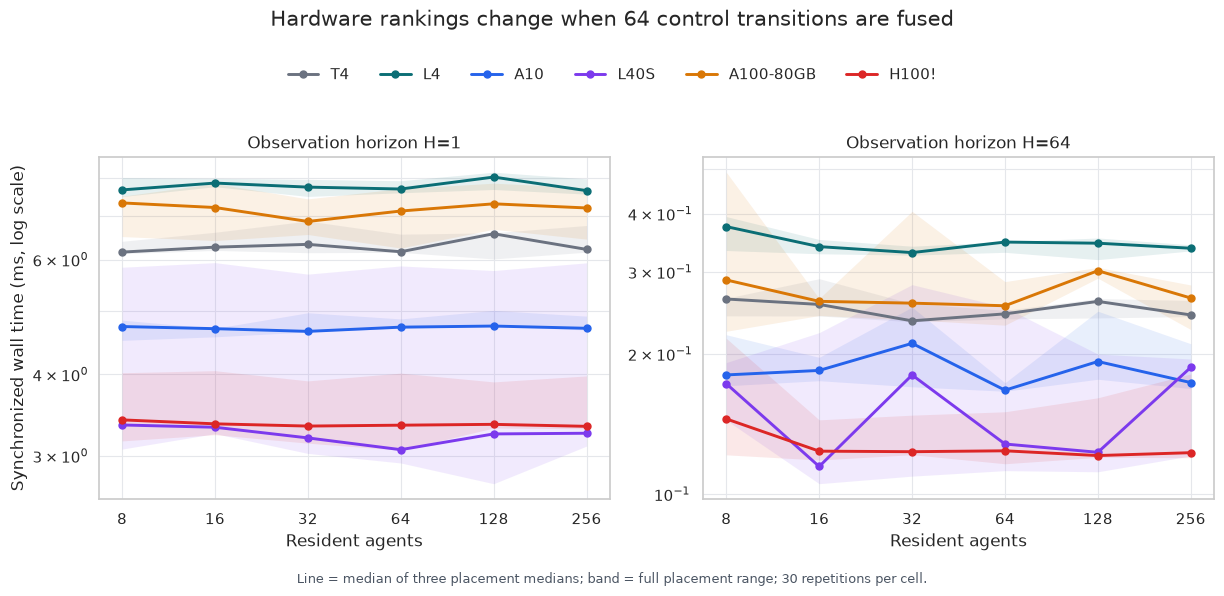

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.9), sharex=True)
for axis, horizon in zip(axes, [1, 64], strict=True):
    panel = aggregate[aggregate["observation_horizon"].eq(horizon)]
    for gpu in GPU_ORDER:
        series = panel[panel["requested_gpu"].eq(gpu)].sort_values("agent_count")
        axis.plot(
            series["agent_count"],
            series["wall_ms_median_of_placement_medians"],
            marker="o", linewidth=2.1, markersize=5,
            color=GPU_COLORS[gpu], label=gpu,
        )
        axis.fill_between(
            series["agent_count"], series["wall_ms_placement_min"],
            series["wall_ms_placement_max"], color=GPU_COLORS[gpu],
            alpha=0.10, linewidth=0,
        )
    axis.set_xscale("log", base=2)
    axis.set_yscale("log")
    axis.set_xticks([8, 16, 32, 64, 128, 256])
    axis.set_xticklabels(["8", "16", "32", "64", "128", "256"])
    axis.set_title(f"Observation horizon H={horizon}")
    axis.set_xlabel("Resident agents")
    axis.grid(True, which="both", color="#E5E7EB", linewidth=0.8)
axes[0].set_ylabel("Synchronized wall time (ms, log scale)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.05))
fig.suptitle("Hardware rankings change when 64 control transitions are fused", y=1.14, fontsize=15)
fig.text(0.5, -0.03, "Line = median of three placement medians; band = full placement range; 30 repetitions per cell.", ha="center", fontsize=9, color="#4B5563")
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(FIGURES / f"hardware-replication-wall-time.{suffix}", dpi=220 if suffix == "png" else None, bbox_inches="tight", facecolor="white")
plt.show()

## One-step CPU/GPU boundary

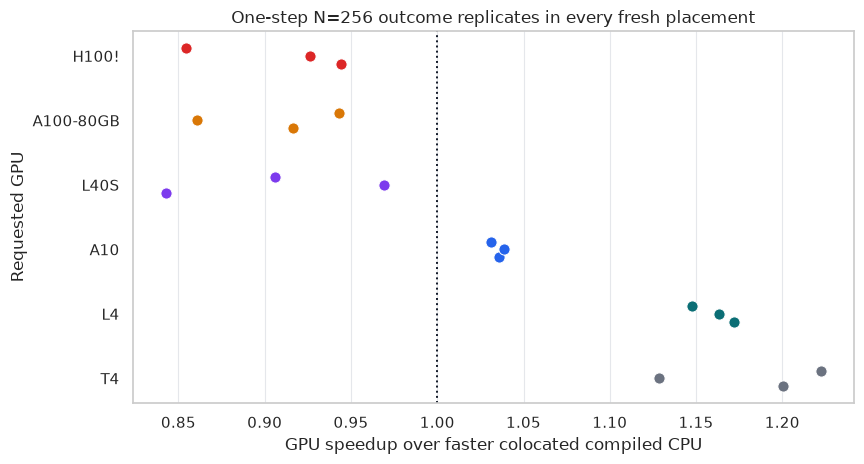

In [4]:
h1_n256 = placement[
    placement["agent_count"].eq(256)
    & placement["observation_horizon"].eq(1)
].copy()
fig, axis = plt.subplots(figsize=(8.8, 4.8))
positions = {gpu: index for index, gpu in enumerate(GPU_ORDER)}
for gpu in GPU_ORDER:
    series = h1_n256[h1_n256["requested_gpu"].eq(gpu)].sort_values("placement_replicate")
    axis.scatter(
        series["speedup_vs_best_cpu"], positions[gpu] + np.array([-0.12, 0.0, 0.12]),
        s=65, color=GPU_COLORS[gpu], edgecolor="white", linewidth=0.7, zorder=3,
    )
axis.axvline(1.0, color="#111827", linestyle=":", linewidth=1.4)
axis.set_yticks(range(len(GPU_ORDER)))
axis.set_yticklabels(GPU_ORDER)
axis.set_xlabel("GPU speedup over faster colocated compiled CPU")
axis.set_ylabel("Requested GPU")
axis.set_title("One-step N=256 outcome replicates in every fresh placement")
axis.grid(True, axis="x", color="#E5E7EB", linewidth=0.8)
axis.grid(False, axis="y")
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(FIGURES / f"hardware-replication-h1-n256-speedup.{suffix}", dpi=220 if suffix == "png" else None, bbox_inches="tight", facecolor="white")
plt.show()

In [5]:
aggregate[
    aggregate["agent_count"].eq(256)
    & aggregate["observation_horizon"].eq(1)
][[
    "requested_gpu", "wall_ms_median_of_placement_medians",
    "speedup_median_of_placements", "speedup_placement_min",
    "speedup_placement_max", "placements_speedup_gt_one",
]].sort_values("speedup_median_of_placements", ascending=False)

,requested_gpu,wall_ms_median_of_placement_medians,speedup_median_of_placements,speedup_placement_min,speedup_placement_max,placements_speedup_gt_one
35,T4,6.219271,1.200488,1.128772,1.222557,3
23,L4,7.653056,1.163336,1.147780,1.172272,3
5,A10,4.706926,1.035902,1.031406,1.038424,3
17,H100!,3.329645,0.926418,0.854430,0.944201,0
11,A100-80GB,7.199317,0.916127,0.860480,0.943184,0
29,L40S,3.249384,0.906234,0.842516,0.969298,0


T4, L4, and A10 beat their colocated tuned CPU in all nine placements; L40S,
A100, and H100 lose in all nine. This is a deployment-level boundary, not a
pure architecture comparison, because CPU hosts differ.

## Cost frontier after temporal fusion

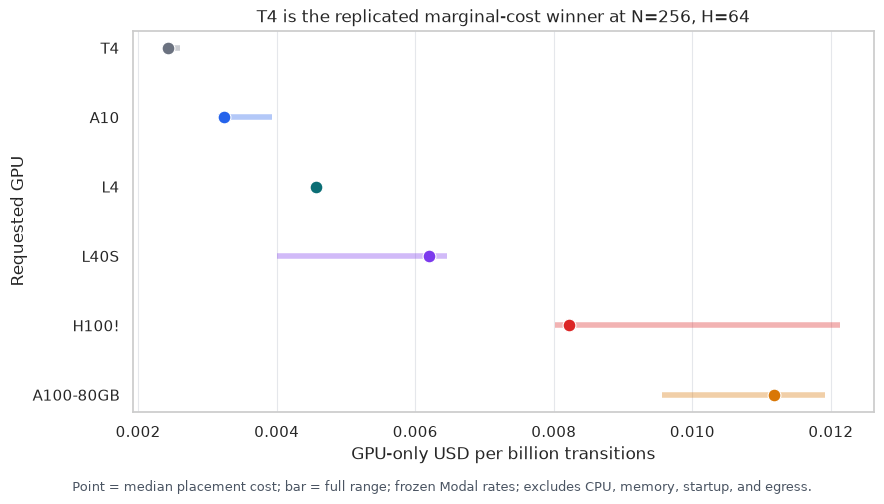

In [6]:
cost_rank = aggregate[
    aggregate["agent_count"].eq(256)
    & aggregate["observation_horizon"].eq(64)
].sort_values("cost_usd_per_billion_median").reset_index(drop=True)
fig, axis = plt.subplots(figsize=(9.0, 4.9))
for index, row in cost_rank.iterrows():
    color = GPU_COLORS[row["requested_gpu"]]
    axis.hlines(index, row["cost_usd_per_billion_placement_min"], row["cost_usd_per_billion_placement_max"], color=color, linewidth=4, alpha=0.35)
    axis.scatter(row["cost_usd_per_billion_median"], index, s=85, color=color, edgecolor="white", linewidth=0.8, zorder=3)
axis.set_yticks(range(len(cost_rank)))
axis.set_yticklabels(cost_rank["requested_gpu"])
axis.invert_yaxis()
axis.set_xlabel("GPU-only USD per billion transitions")
axis.set_ylabel("Requested GPU")
axis.set_title("T4 is the replicated marginal-cost winner at N=256, H=64")
axis.grid(True, axis="x", color="#E5E7EB", linewidth=0.8)
axis.grid(False, axis="y")
fig.text(0.5, -0.02, "Point = median placement cost; bar = full range; frozen Modal rates; excludes CPU, memory, startup, and egress.", ha="center", fontsize=9, color="#4B5563")
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(FIGURES / f"hardware-replication-cost-frontier.{suffix}", dpi=220 if suffix == "png" else None, bbox_inches="tight", facecolor="white")
plt.show()

In [7]:
cost_rank[[
    "requested_gpu", "wall_ms_median_of_placement_medians",
    "wall_ms_placement_min", "wall_ms_placement_max",
    "speedup_median_of_placements", "cost_usd_per_billion_median",
    "cost_usd_per_billion_placement_min", "cost_usd_per_billion_placement_max",
]]

,requested_gpu,wall_ms_median_of_placement_medians,wall_ms_placement_min,wall_ms_placement_max,speedup_median_of_placements,cost_usd_per_billion_median,cost_usd_per_billion_placement_min,cost_usd_per_billion_placement_max
0,T4,0.242636,0.240619,0.260589,4.743954,0.002429,0.002409,0.002608
1,A10,0.173658,0.168572,0.210405,3.902962,0.003243,0.003148,0.003930
2,L4,0.337395,0.332958,0.343122,3.808400,0.004572,0.004512,0.004649
3,L40S,0.187224,0.120882,0.195151,3.655814,0.006194,0.003999,0.006456
4,H100!,0.122803,0.119787,0.181246,4.519026,0.008222,0.008020,0.012135
5,A100-80GB,0.263769,0.225711,0.281320,3.269766,0.011173,0.009561,0.011916


H100 is the fastest fused card at 0.123 ms; T4 is fourth in latency but first
in marginal cost. T4's median is `$0.00243` per billion transitions versus
H100's `$0.00822` and A100's `$0.01117`. Four cheaper classes beat H100 cost
in all three placement indices.

Across all 108 placement/population combinations, fusing 64 transitions helps
the GPU proportionally more than the tuned CPU (1.62×–5.88×). At `N=8,H=64`,
even the weakest placement speedup is 1.39×.

## Limits

The CPU baseline is matched PyTorch compilation, not an optimized
C++/OpenMP/SIMD ceiling. The GPU path is PyTorch Inductor, not a custom CUDA,
CUDA Graph, or persistent-kernel ceiling. Marginal cost excludes container
lifetime, compilation, CPU/memory, and provider minimums. The next layer needs
custom kernels, power, shared-LLM interference, and another provider.